In [1]:
# ==========================================================
# Crop Identification Dataset Preparation
# ==========================================================

In [2]:
import os
import shutil
import random 
from pathlib import Path
import cv2
import matplotlib.pyplot as plt 
from PIL import Image
from sklearn.model_selection import train_test_split
import pandas as pd

In [3]:
DATASET_PATH = r"../dataset"

In [4]:
IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
)
classes = sorted(
    [
        folder.name
        for folder in Path(DATASET_PATH).iterdir()
        if folder.is_dir()
    ]
)
summary = []

for cls in classes:
    images = []
    for ext in IMAGE_EXTENSIONS:
        images.extend(Path(DATASET_PATH, cls).glob(f"*{ext}"))
    summary.append(
        {
            "Class": cls,
            "Images": len(images)
        }
    )

df = pd.DataFrame(summary)
display(df)
print()
print("Total Images :", df["Images"].sum())

,Class,Images
0,BellPepper,1477
1,Chilli,2195
2,Cotton,1691
3,Groundnut,2745
4,Potato,1532
5,Tomato,1591



Total Images : 11231


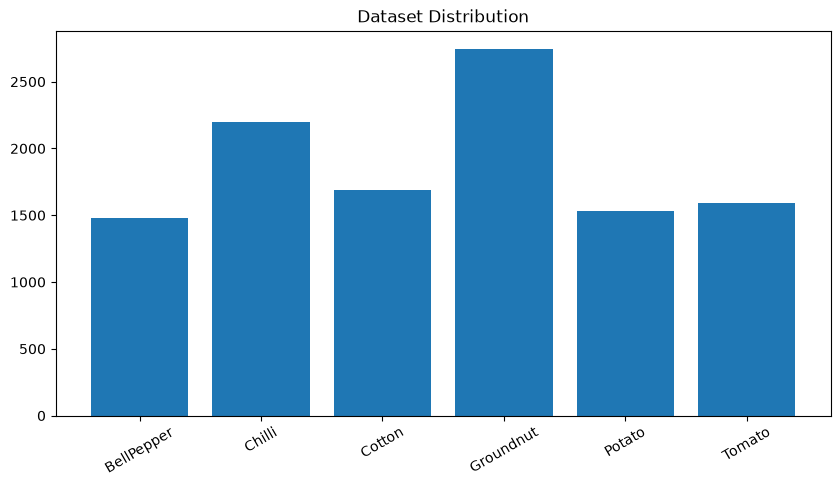

In [5]:
plt.figure(figsize=(10,5))
plt.bar(df["Class"],df["Images"])
plt.xticks(rotation=30)
plt.title("Dataset Distribution")
plt.show()

In [6]:
bad_images = []

for cls in classes:
    folder = Path(DATASET_PATH)/cls
    for image_path in folder.iterdir():
        try:
            img = Image.open(image_path)
            img.verify()
        except:
            bad_images.append(image_path)

print("Bad Images :",len(bad_images))

Bad Images : 0


In [7]:
for img in bad_images:
    os.remove(img)

print("Removed",len(bad_images),"images")

Removed 0 images


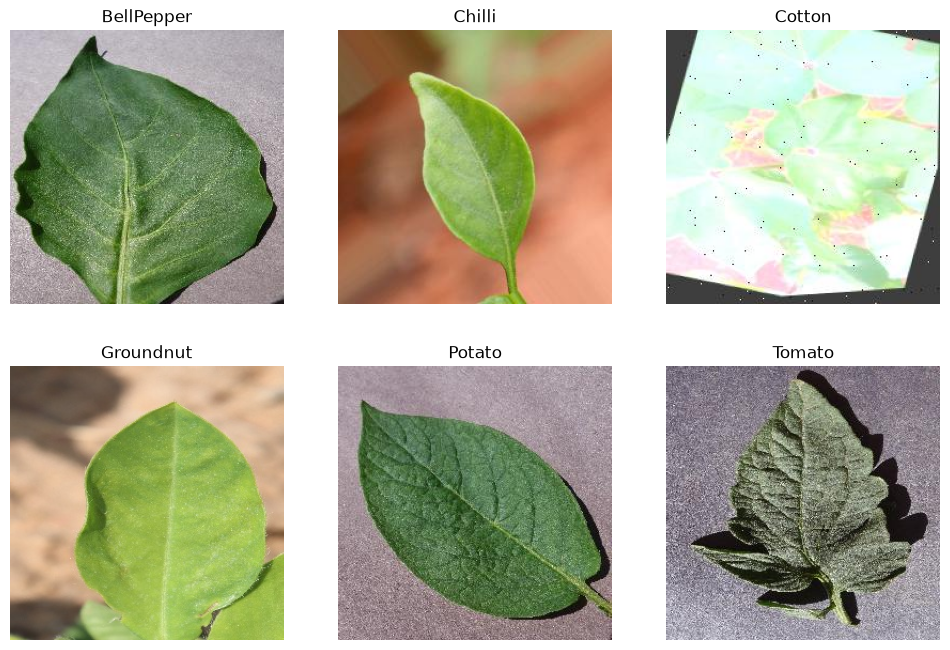

In [8]:
fig,ax = plt.subplots(2,3,figsize=(12,8))
ax=ax.flatten()

for i,cls in enumerate(classes):
    folder=Path(DATASET_PATH)/cls
    img=random.choice(list(folder.iterdir()))
    image=cv2.imread(str(img))
    image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
    ax[i].imshow(image)
    ax[i].set_title(cls)
    ax[i].axis("off")

plt.show()

In [9]:
OUTPUT_PATH="processed_dataset"
splits=["train","val","test"]

for split in splits:
    for cls in classes:
        Path(
            OUTPUT_PATH,
            split,
            cls
        ).mkdir(
            parents=True,
            exist_ok=True
        )

In [10]:
random.seed(42)

for cls in classes:
    folder=Path(DATASET_PATH)/cls
    images=list(folder.iterdir())

    train,temp=train_test_split(
        images,
        test_size=0.2,
        random_state=42
    )

    val,test=train_test_split(
        temp,
        test_size=0.5,
        random_state=42
    )

    for img in train:
        shutil.copy(
            img,
            Path(
                OUTPUT_PATH,
                "train",
                cls,
                img.name
            )
        )

    for img in val:
        shutil.copy(
            img,
            Path(
                OUTPUT_PATH,
                "val",
                cls,
                img.name
            )
        )

    for img in test:
        shutil.copy(
            img,
            Path(
                OUTPUT_PATH,
                "test",
                cls,
                img.name
            )
        )

In [11]:
summary=[]

for split in splits:
    for cls in classes:
        count=len(
            list(
                Path(
                    OUTPUT_PATH,
                    split,
                    cls
                ).iterdir()
            )
        )
        summary.append(
            {
                "Split":split,
                "Class":cls,
                "Images":count
            }

        )

split_df=pd.DataFrame(summary)
display(split_df)

,Split,Class,Images
0,train,BellPepper,1181
1,train,Chilli,1756
2,train,Cotton,1352
3,train,Groundnut,2196
4,train,Potato,1225
5,train,Tomato,1272
6,val,BellPepper,148
7,val,Chilli,219
8,val,Cotton,169
9,val,Groundnut,274


In [12]:
import json

class_to_idx={
    cls:i
    for i,cls in enumerate(classes)
}

with open("classes.json","w") as f:
    json.dump(
        class_to_idx,
        f,
        indent=4
    )

print(class_to_idx)

{'BellPepper': 0, 'Chilli': 1, 'Cotton': 2, 'Groundnut': 3, 'Potato': 4, 'Tomato': 5}


processed_dataset/
    train/
        Chilli/
        Cotton/
        Groundnut/
        BellPepper/
        Potato/
        Tomato/
    val/
        ...
    test/
        ...

Dataset Ready
Train
Validation
Test
classes.json
Ready for Notebook-02